In [1]:
!git clone https://github.com/seasonSH/WarpGAN.git
%cd ~/WarpGAN

!pip install pillow opencv-python scipy tqdm imageio

fatal: destination path 'WarpGAN' already exists and is not an empty directory.
/home/jarvis/WarpGAN


In [2]:
from pathlib import Path

detector_file = Path("align/mtcnntf/detect_face.py")
text = detector_file.read_text()

text = text.replace(
    "np.load(data_path, encoding='latin1').item()",
    "np.load(data_path, allow_pickle=True, encoding='latin1').item()"
)

detector_file.write_text(text)
print("detect_face.py patched")

detect_face.py patched


Saved: /mnt/g/03115P_256.jpg


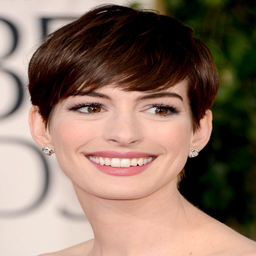

In [3]:
from PIL import Image

INPUT_IMAGE = "/mnt/g/03115P.jpg"
ALIGNED_IMAGE = "/mnt/g/03115P_256.jpg"

img = Image.open(INPUT_IMAGE).convert("RGB")
img = img.resize((256, 256), Image.LANCZOS)
img.save(ALIGNED_IMAGE)

print("Saved:", ALIGNED_IMAGE)
img

In [4]:
%%writefile test.py
import os

# Force CPU to avoid TensorFlow 1.x + modern RTX GPU cuBLAS/xGEMM crashes
os.environ["CUDA_VISIBLE_DEVICES"] = ""
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

import argparse
import numpy as np
from pathlib import Path
from PIL import Image
import imageio.v2 as imageio

from warpgan import WarpGAN


def load_rgb_image(path):
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(f"Input image not found: {path}")
    return np.array(Image.open(path).convert("RGB"))


def save_outputs(output_prefix, output_images):
    output_prefix = str(output_prefix)
    for i in range(output_images.shape[0]):
        out_path = f"{output_prefix}_{i}.jpg"
        imageio.imwrite(out_path, output_images[i])
        print(f"Saved: {out_path}")


def main():
    parser = argparse.ArgumentParser()
    parser.add_argument("model_dir", type=str)
    parser.add_argument("input", type=str)
    parser.add_argument("output", type=str)
    parser.add_argument("--num_styles", type=int, default=1)
    parser.add_argument("--scale", type=float, default=1.0)
    parser.add_argument("--aligned", action="store_true")
    parser.add_argument("--seed", type=int, default=42)
    args = parser.parse_args()

    np.random.seed(args.seed)

    model_dir = Path(args.model_dir)
    if not model_dir.exists():
        raise FileNotFoundError(f"Model directory not found: {model_dir}")

    network = WarpGAN()
    network.load_model(str(model_dir))

    img = load_rgb_image(args.input)

    if not args.aligned:
        from align.detect_align import detect_align
        img = detect_align(img)

    img = img.astype(np.float32)
    img = (img - 127.5) / 128.0

    images = np.tile(img[None], [args.num_styles, 1, 1, 1]).astype(np.float32)
    scales = (args.scale * np.ones((args.num_styles,), dtype=np.float32))

    style_dim = network.input_style.shape[1].value
    styles = np.random.normal(
        0.0, 1.0, (args.num_styles, style_dim)
    ).astype(np.float32)

    output = network.generate_BA(images, scales, 16, styles=styles)

    output = 0.5 * output + 0.5
    output = np.clip(output * 255.0, 0, 255).astype(np.uint8)

    save_outputs(args.output, output)


if __name__ == "__main__":
    main()

Overwriting test.py


In [5]:
from pathlib import Path

warpgan_file = Path("warpgan.py")
text = warpgan_file.read_text()

text = text.replace("tf.GPUOptions", "tf.compat.v1.GPUOptions")
text = text.replace("tf.ConfigProto", "tf.compat.v1.ConfigProto")
text = text.replace("tf.Session", "tf.compat.v1.Session")
text = text.replace("tf.train.import_meta_graph", "tf.compat.v1.train.import_meta_graph")

if "allow_growth=True" not in text:
    text = text.replace(
        "gpu_options = tf.compat.v1.GPUOptions()",
        "gpu_options = tf.compat.v1.GPUOptions(allow_growth=True)"
    )

warpgan_file.write_text(text)
print("warpgan.py patched")

warpgan.py patched


In [6]:
MODEL_DIR = "/mnt/g/warpgan_pretrained"
INPUT_IMAGE = "/mnt/g/03115P.jpg"
ALIGNED_IMAGE = "/mnt/g/03115P_256.jpg"
OUTPUT_PREFIX = "/mnt/g/warpgan_results/result"

In [7]:
!ls -lh "$MODEL_DIR"
!cat "$MODEL_DIR/checkpoint"

total 628M
-rwxrwxrwx 1 jarvis jarvis  857 Apr  9  2019 checkpoint
-rwxrwxrwx 1 jarvis jarvis 624M Apr 12  2019 ckpt-100000.data-00000-of-00001
-rwxrwxrwx 1 jarvis jarvis 3.6K Apr  9  2019 ckpt-100000.index
-rwxrwxrwx 1 jarvis jarvis 2.1K Apr  9  2019 config.py
-rwxrwxrwx 1 jarvis jarvis 4.1M Apr  9  2019 graph.meta
-rwxrwxrwx 1 jarvis jarvis  15K Apr  9  2019 network.py
drwxrwxrwx 1 jarvis jarvis  512 Apr  9  2019 samples
model_checkpoint_path: "ckpt-100000"
all_model_checkpoint_paths: "ckpt-5000"
all_model_checkpoint_paths: "ckpt-10000"
all_model_checkpoint_paths: "ckpt-15000"
all_model_checkpoint_paths: "ckpt-20000"
all_model_checkpoint_paths: "ckpt-25000"
all_model_checkpoint_paths: "ckpt-30000"
all_model_checkpoint_paths: "ckpt-35000"
all_model_checkpoint_paths: "ckpt-40000"
all_model_checkpoint_paths: "ckpt-45000"
all_model_checkpoint_paths: "ckpt-50000"
all_model_checkpoint_paths: "ckpt-55000"
all_model_checkpoint_paths: "ckpt-60000"
all_model_checkpoint_paths: "ckpt-65000"
all_

In [8]:
!python -u test.py "$MODEL_DIR" "$ALIGNED_IMAGE" "$OUTPUT_PREFIX" --num_styles 1 --scale 1.0 --aligned

2026-03-22 19:05:54.634967: E tensorflow/stream_executor/cuda/cuda_driver.cc:318] failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected
Metagraph file: /mnt/g/warpgan_pretrained/graph.meta
Checkpoint file: /mnt/g/warpgan_pretrained/ckpt-100000
Saved: /mnt/g/warpgan_results/result_0.jpg


In [9]:
!ls -lh /mnt/g/warpgan_results/result*

-rwxrwxrwx 1 jarvis jarvis 11K Mar 22 19:05 /mnt/g/warpgan_results/result_0.jpg


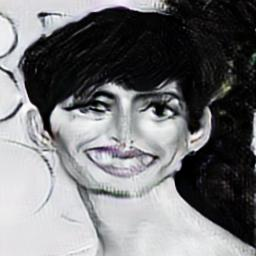

In [10]:
from PIL import Image
Image.open("/mnt/g/warpgan_results/result_0.jpg")

In [11]:
!python -u test.py "$MODEL_DIR" "$ALIGNED_IMAGE" "$OUTPUT_PREFIX" --num_styles 5 --scale 1.0 --aligned

2026-03-22 19:06:00.418913: E tensorflow/stream_executor/cuda/cuda_driver.cc:318] failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected
Metagraph file: /mnt/g/warpgan_pretrained/graph.meta
Checkpoint file: /mnt/g/warpgan_pretrained/ckpt-100000
Saved: /mnt/g/warpgan_results/result_0.jpg
Saved: /mnt/g/warpgan_results/result_1.jpg
Saved: /mnt/g/warpgan_results/result_2.jpg
Saved: /mnt/g/warpgan_results/result_3.jpg
Saved: /mnt/g/warpgan_results/result_4.jpg
